<font size="6"> **ENG 07044 - Controle de Processos Industriais / DEQUI / UFRGS** </font>

<font size="5">
Chuveirto Turbinado: Tanque de mistrura, boiler e Tubulação Longa
</font>


         Prof. Dr. Jorge Otávio Trierweiler -- Jorge.Trierweiler@ufrgs.br


### Passo 1: Modelagem e Configuração do Ambiente
* Implementação das Equações Diferenciais Ordinárias (EDOs) do sistema.
* Configuração do ambiente de simulação em Python (NumPy, SciPy, Control).

In [1]:
# Importação de pacotes
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as wg
import control.matlab as ml
from scipy import signal as sg
from scipy.integrate import solve_ivp
from math import sqrt

from plotly.subplots import make_subplots
import plotly.graph_objects as go

import plotly.io as pio
pio.templates.default = 'plotly_dark'
Opcoes = ['ggplot2', 'seaborn', 'simple_white', 'plotly',
         'plotly_white', 'plotly_dark', 'presentation', 'xgridoff',
         'ygridoff', 'gridon', 'none'];

%matplotlib inline

In [2]:
def Plota( x, Dados1, Dados2=None,  tit = 'Sinais', xlabel='Tempo', ylabel1 = 'Saídas', ylabel2 ='Entradas'):
    # Função para fazer os plotes usando o plotly
    # x -- vetor das abcissas -- normalmente tempo
    # Dados1 -- dicionário contendo os dados que serão plotados no primeiro subplot
    # Dados2 -- dicionário contendo os dados do segundo subplote -- quando for NONE será feito apenas um plote
    # tit é o título
    # xlabel 
    # ylabel
    
    if Dados2 == None:
        fig = make_subplots(1,1)
    else: 
        fig = make_subplots(2,1)
    
    str = list(Dados1.keys())
    for k in range(len(str)):
        stt ='spline'
        if str[k][0] == 'S':
            stt = 'hv'
        fig.add_trace(go.Scatter(name=str[k], x=x, y=Dados1[str[k]], line_shape = stt),1,1)
        
    if Dados2 != None:
        str = list(Dados2.keys())
        for k in range(len(str)):
            fig.add_trace(go.Scatter(name=str[k], x=x, y=Dados2[str[k]],line={'shape':'hv'}),2,1)
        
    fig.update_xaxes(matches='x')
    fig.update_xaxes(title_text= xlabel, row=2, col=1)
    fig.update_yaxes(title_text =ylabel2, row=2, col=1)
    fig.update_layout(height=500, width = 800,
            title={'text': tit,'y':0.85,'x':0.5,
            'xanchor': 'center', 'yanchor': 'top'},
            #xaxis_title = ylabel2,
            yaxis_title=  ylabel1, legend_title="Variáveis")
    fig.show() 

# Válvulas de controle

In [3]:
# modelo para a válvula de alimentação da corrente quente

def AlimentacaoQuente(xf,xq):
    t = 60*(xq**(8/5))
    n = -1*(-180 - 45*(xf**2) - 250*(xq**(16/5))*(xf**2) - 1180*(xq**(16/5)) + 60*sqrt(9*(xq**(16/5))*(xf**2) + 50*(xq**(32/5))*(xf**2)))
    d = 6552*(xq**(16/5))*(xf**2) + 648*(xf**2) + 16400*(xq**(32/5))*(xf**2) + 900*(xq**(16/5))*(xf**4) + 2500*(xq**(32/5))*(xf**4) + 81*(xf**4) + 55696*(xq**(32/5)) + 16992*(xq**(16/5)) + 1296
    Fq = t*sqrt(n/d)
    return Fq

In [4]:
# modelo para a válvula de alimentação da corrente fria

def AlimentacaoFria(xf,Fq):
    n = 2*xf*sqrt(125*xf*xf - Fq*Fq + 500) - xf*Fq
    d = (xf**2) + 4
    Ff = n/d
    return Ff

In [5]:
# modelo para a válvula de saída

def Saida(xs):
    n = 5*(xs**3)*(sqrt(30))*sqrt(-15*(xs**6) + sqrt(6625*(xs**12) + 640*(xs**6) + 16))
    d = 20*(xs**6) + 1
    Fs = n/d
    return Fs

# Boiler

In [6]:
# modelo para o aquecedor de passagem

def Boiler(t,Tq,
           Fq,Tf,Sa):
    
    # EDO -- Atenção -- foi alterado o valor que multiplica Sa por 3 em relação ao valor documentado
    return Fq*(Tf - Tq) + 300*Sa

# Tanque com aquecedor

In [7]:
# modelo para o balanço de massa do tanque

def Nivel(t,h,
          Ff,Fq,Fd,Fs):
    
    # EDO
    return (1/0.5)*(Ff + Fq + Fd - Fs)

In [8]:
# modelo para o tanque de aquecimento com mistura

def Tanque(t,Tt,
           Ff,Tf,Fq,Tq,Fd,Td,Sr,h):
    
    # EDO
    return (1/(0.5*h))*(Ff*(Tf-Tt) + Fq*(Tq-Tt) + Fd*(Td-Tt) + 80*Sr)

# Tubulação

In [9]:
# modelo para a tubulação de saída

def Tubulacao(t,Ts,
             Tt,Fs,Tinf):
    
    # EDO
    return (Fs/2.5)*(Tt-Ts) - 0.8*(((Tt-Tinf)*(Ts-Tinf)*(0.5*(Tt-Tinf) + 0.5*(Ts-Tinf)))**(1/3))

# Controladores

In [10]:
def OnOff(Uop, medido,minimo,maximo):
    if medido < minimo:
        Uop = 1
    elif medido > maximo:
        Uop = 0
    return Uop

In [11]:
def PID(SP, PV, j, I_int, D_int, dt, Kp, Ti, Td, b, c, N, U_bias, Umin, Umax, Method = 'Backward'):
    
    if Method == 'Backward':
        b1 = Kp*dt/Ti if Ti!=0 else 0.0
        b2 = 0.0
        ad = Td/(Td+N*dt)
        bd = Kp*Td*N/(Td+N*dt)
    elif Method == 'Forward':
        b1 = 0.0
        b2 = Kp*dt/Ti  if Ti!=0 else 0.0
        ad = 1-N*dt/Td if Td!=0 else 0.0
        bd = Kp*N   
    elif Method == 'Tustin':
        b1 = Kp*dt/2/Ti if Ti!=0 else 0.0
        b2 = b1
        ad = (2*Td-N*dt)/(2*Td+N*dt)
        bd = 2*Kp*Td*N/(2*Td+N*dt)   
    elif Method == 'Ramp':
        b1 = Kp*dt/2/Ti if Ti!=0 else 0.0
        b2 = b1
        ad = np.exp(-N*dt/Td) if Td!=0 else 0.0
        bd = Kp*Td*(1-ad)/dt
        
    # Derivative action 
    D = ad*D_int + bd*((c*SP[j]-PV[j]) - (c*SP[j-1]-PV[j-1]))
    
    # Integral action
    II = b1*(SP[j]-PV[j]) + b2*(SP[j-1]-PV[j-1])
    I = I_int + II                         
   
    # Proportional action
    P = Kp * (b*SP[j]-PV[j])
    
    # calculate the PID output
    Uop = U_bias + P + I + D

    # implement anti-reset windup
    if Uop < Umin:
        II = 0.0
        Uop = Umin
    if Uop > Umax:
        II = 0.0
        Uop = Umax
    I = I_int + II
    
    # return the controller output and PID terms
    return np.array([ Uop, I, D])

# Sistema

In [12]:
def ModelagemSistema(t,Y,
                    Sa, xf,xq,xs, Tf,Td,Tinf,Fd,Sr):
    N   = 50
    Vt  = 5
    UAt = 0.01
    Fq = AlimentacaoQuente(xf,xq)
    Ff = AlimentacaoFria(xf,Fq)
    Fs = Saida(xs)
    #print((Fq,Ff,Fs, Fs-Fq-Ff))
    
    Tq = Y[0]
    h  = Y[1]
    Tt = Y[2]
    #T = Y[3]
    
    EDOTq = Boiler(t,Tq,Fq,Tf,Sa)
    EDOh = Nivel(t,h,Ff,Fq,Fd,Fs)
    EDOTt = Tanque(t,Tt,Ff,Tf,Fq,Tq,Fd,Td,Sr,h)
    #EDOTs = Tubulacao(t,Ts,Tt,Fs,Tinf) # versão apresentada no arquivo word -- só que sem o tempo morto
    # a seguir a tubulação longa está implementada discretizando a tubulação -- nos mesmos moldes da implementação feita no arquivo 00_Introdução_Malhas_de_Controle
    return np.array([EDOTq,EDOh,EDOTt]+list((N-1)/Vt*(Fs*(Y[2:N+1]-Y[3:N+2])-UAt*(Y[3:N+2]-Tinf))))

# Malhas de nível, temperatura do boiler e Temperatura Tanque em automático

In [13]:
def Simulacao_MF1(SYS, Y0, UT, dt): 
    # Y0 = [Tq, h, Tt, Ts]
    # Modelo do sistema, vetor de valores iniciais, matriz de perturbações, intervalo de tempo
    # Versão com malha de inventório de nível e temperatura on-off para a temperatura de alimentação
    
    # Armazenamento dos dados resultantes da simulação
    tempoFinal = UT[-1,0] 
    TT = np.arange(start = 0, stop = tempoFinal+dt, step = dt, dtype='float') # instantes de tempo
    nt = np.size(TT)
    ny = 4
    id = [0,1,2,-1]
    # matriz para armazenar valores das variáveis de saída para cada instante de tempo inicializando com os valores 
    # relativos a condição incial, ou seja, Y0
    YY = np.ones((nt,ny))@np.diag(Y0[id])
    SP = np.ones((nt,ny))@np.diag(Y0[id])
    
    nu = np.size(UT,1)
    UU = np.zeros((nt,nu-1)) # matriz para armazenar valores das variáveis de entrada para cada instante de tempo

    # malhas de controle seguirão o seguinte padrão
    # 0 -- malha controle de temperatura do boiler -- controlador liga-desliga
    # 1 -- malha de nível h 
    # 2 -- malha de temperatura do tanque
    # 3 -- malha de vazão de saída
    
    
    # malhas de controle 
    #                    Tq,  h ,  T1, Ts
    Kp      = np.array([ 1, 0.3, 0.6, 0.5])
    Ti      = np.array([ 1, 0.8, 0.8, 0.5])
    Td      = np.array([ 1, 0.0, 0.0, 0.0])
    b       = np.array([ 1, 1.0, 1.0, 1.0])
    c       = np.array([ 0,   0,  0,    0])
    # Sa, xf, xq,xs, Tf,Td,Tinf,Fd,Sr
    UU_bias = np.array([ 0, 0.25,0.25,0.50])
    UU_min  = np.array([ 0, 0.01,0.01,0.01])
    UU_max  = np.array([ 1, 0.99,0.99,0.99])
    D_int = np.array ([0, 0,0 ,0])  
    I_int = Kp*Y0[id]*(1-b)
    N = 10
    
    # Simulação
    ii = 0
    N_PIDs = 1 # número de malhas pid que estão fechadas
    for k in np.arange(nt-1):
        if TT[k] >= UT[ii+1,0]:
            ii=ii+1

        UU[k,:] = UT[ii,1:nu] # inicialisando os valores 
        
        # Controle do boiler -- índice 0 para boiler
        SP[k,0] = UU[k,0]
        UU[k,0] = OnOff(UU[k-1,0],YY[k,0],SP[k,0]-1,SP[k,0]+1)
        
        
        # Malhas de controle PIDs
        for jj in [1,2]:
            SP[k,jj] = UU[k,jj]
            uu = PID(SP[:,jj], YY[:,jj], k, I_int[jj], D_int[jj], dt, Kp[jj], Ti[jj], Td[jj], b[jj], c[jj],
                     N, U_bias=UU_bias[jj], Umin=UU_min[jj],Umax=UU_max[jj])
            
                
            UU[k,jj]  = uu[0]
            
            I_int[jj] = uu[1]
            D_int[jj] = uu[2]
        
        
        sol = solve_ivp(SYS, [TT[k],TT[k+1]], Y0, args=tuple(UU[k]), atol= 1e-8, rtol=1e-8) 
        
        # Armazenamento dos valores calculados
        Y0 =sol.y[:,-1]
        YY[k+1,:] = sol.y[id,-1]
                
    UU[k+1,:]=UU[k,:]  
    SP[k+1,:]=SP[k,:]
    
    
    Plota(TT,
      {'Tq': YY[:,0],'SP_Tq':SP[:,0]},
      {'xf': UU[:,1], 'xq':UU[:,2],'xs': UU[:,3], 'Sa':UU[:,0]},
      tit = "Malha Boiler", xlabel = 'Tempo')
      
    Plota(TT,
      { 'h': YY[:,1],'SPh':SP[:,1]},
      {'xf': UU[:,1], 'xq':UU[:,2],'xs': UU[:,3]},
      tit = "Malha Nível", xlabel = 'Tempo')
    
    Plota(TT,
      { 'T1':YY[:,2], 'SP_T1': SP[:,2],'Ts':YY[:,3]},
      {'xf': UU[:,1], 'xq':UU[:,2],'xs': UU[:,3]},
      tit = "Malha Temperatura", xlabel = 'Tempo')
        
    return (TT,YY,UU)

In [14]:
# Sa, xf, xq,xs, Tf,Td,Tinf,Fd,Sr
Ta = 28 #temperatura ambiente
UT = np.array([# Time, SPTq, SPh, SP_T1,   xs,    Tf,   Td,  Tinf, Fd, Sr
              [  0  ,    45,  90,    32,  0.8,    Ta,   Ta,    Ta,  0, 0],
              [  3  ,    45,  80,    35,  0.8,    Ta,   Ta,    Ta,  0, 0],
              [  8  ,    55,  85,    36,  0.7,    Ta,   Ta,    Ta,  0, 0],
              [  12 ,    50,  90,    35,  0.7,    Ta,   Ta,    Ta,  0, 0],
              [  16 ,    45,  90,    35,  0.8,    Ta,   Ta,    Ta,  0, 0]
    
])         
'''
UT = np.array([# Time, SPq, SPh, xq, xs,Tf, Td, Tinf, Fd, Sr
              [  0  , 45, 90,  0.25, 0.5, 30, 30, 20,  0, 0],
              [  2  , 45, 90,  0.25, 0.5, 30, 30, 20,  0, 0],
              [  8  , 35, 90,  0.25, 0.5, 30, 30, 25,  0, 0],
              [  10 , 35, 90,  0.25, 0.5, 30, 30, 25,  0, 0]
    
])             
'''
TT, YY, UU = Simulacao_MF1(ModelagemSistema, np.array([45,90]+50*[Ta]), UT, 0.05)

# Versão com split range no controle de temperatura do tanque (T_1)

In [15]:
def Simulacao_MF_split(SYS, Y0, UT, dt): 
    # Y0 = [Tq, h, Tt, Ts]
    # Modelo do sistema, vetor de valores iniciais, matriz de perturbações, intervalo de tempo
    # Versão com malha de inventório de nível e temperatura on-off para a temperatura de alimentação
    
    # Armazenamento dos dados resultantes da simulação
    tempoFinal = UT[-1,0] 
    TT = np.arange(start = 0, stop = tempoFinal+dt, step = dt, dtype='float') # instantes de tempo
    nt = np.size(TT)
    ny = 4
    id = [0,1,2,-1]
    # matriz para armazenar valores das variáveis de saída para cada instante de tempo inicializando com os valores 
    # relativos a condição incial, ou seja, Y0
    YY = np.ones((nt,ny))@np.diag(Y0[id])
    SP = np.ones((nt,ny))@np.diag(Y0[id])
    
    nu = np.size(UT,1)
    UU = np.zeros((nt,nu-1)) # matriz para armazenar valores das variáveis de entrada para cada instante de tempo

    # malhas de controle seguirão o seguinte padrão
    # 0 -- malha controle de temperatura do boiler -- controlador liga-desliga
    # 1 -- malha de nível h 
    # 2 -- malha de temperatura do tanque
    # 3 -- malha de vazão de saída
    
    
    # malhas de controle 
    #                    Tq,  h ,  T1, Ts
    Kp      = np.array([ 1, 0.3, 0.6, 0.5])
    Ti      = np.array([ 1, 0.8, 0.8, 0.5])
    Td      = np.array([ 1, 0.0, 0.0, 0.0])
    b       = np.array([ 1, 1.0, 1.0, 1.0])
    c       = np.array([ 0,   0,  0,    0])
    # Sa, xf, xq,xs, Tf,Td,Tinf,Fd,Sr
    UU_bias = np.array([ 0, 0.25,0.25,0.50])
    UU_min  = np.array([ 0, 0.01,0.01,0.01])
    UU_max  = np.array([ 1, 0.99,1.99,0.99])
    D_int = np.array ([0, 0,0 ,0])  
    I_int = Kp*Y0[id]*(1-b)
    N = 10
    
    # Simulação
    ii = 0
    N_PIDs = 1 # número de malhas pid que estão fechadas
    for k in np.arange(nt-1):
        if TT[k] >= UT[ii+1,0]:
            ii=ii+1

        UU[k,:] = UT[ii,1:nu] # inicialisando os valores 
        
        # Controle do boiler -- índice 0 para boiler
        SP[k,0] = UU[k,0]
        UU[k,0] = OnOff(UU[k-1,0],YY[k,0],SP[k,0]-1,SP[k,0]+1)
        
        
        # Malhas de controle PIDs
        for jj in [1,2]:
            SP[k,jj] = UU[k,jj]
            uu = PID(SP[:,jj], YY[:,jj], k, I_int[jj], D_int[jj], dt, Kp[jj], Ti[jj], Td[jj], b[jj], c[jj],
                     N, U_bias=UU_bias[jj], Umin=UU_min[jj],Umax=UU_max[jj])
            
            if jj==2 and uu[0]>1: #split range para controlar a temperatura do tanque
                UU[k,jj] = 1
                UU[k,-1] = uu[0]-1
            else:
                UU[k,jj]  = uu[0]
            
            I_int[jj] = uu[1]
            D_int[jj] = uu[2]
        
        
        sol = solve_ivp(SYS, [TT[k],TT[k+1]], Y0, args=tuple(UU[k]), atol= 1e-8, rtol=1e-8) 
        
        # Armazenamento dos valores calculados
        Y0 =sol.y[:,-1]
        YY[k+1,:] = sol.y[id,-1]
                
    UU[k+1,:]=UU[k,:]  
    SP[k+1,:]=SP[k,:]
    
    
    Plota(TT,
      {'Tq': YY[:,0],'SP_Tq':SP[:,0]},
      {'xf': UU[:,1], 'xq':UU[:,2],'xs': UU[:,3], 'Sa':UU[:,0]},
      tit = "Malha Boiler", xlabel = 'Tempo')
      
    Plota(TT,
      { 'h': YY[:,1],'SPh':SP[:,1]},
      {'xf': UU[:,1], 'xq':UU[:,2],'xs': UU[:,3]},
      tit = "Malha Nível", xlabel = 'Tempo')
    
    Plota(TT,
      { 'T1':YY[:,2], 'SP_T1': SP[:,2],'Ts':YY[:,3]},
      {'xf': UU[:,1], 'xq':UU[:,2],'xs': UU[:,3],'Sr':UU[:,-1]},
      tit = "Malha Temperatura", xlabel = 'Tempo')
        
    return (TT,YY,UU)

In [16]:
# Sa, xf, xq,xs, Tf,Td,Tinf,Fd,Sr
Ta = 30 #temperatura ambiente
UT = np.array([# Time, SPTq, SPh, SP_T1,   xs,    Tf,   Td,  Tinf, Fd, Sr
              [  0  ,    45,  90,    30,  0.8,    Ta,   Ta,    Ta,  0, 0],
              [  3  ,    45,  80,    35,  0.8,    Ta,   Ta,    Ta,  0, 0],
              [  8  ,    55,  85,    36,  0.7,    Ta,   Ta,    Ta,  0, 0],
              [  12 ,    50,  90,    35,  0.7,    Ta,   Ta,    Ta,  0, 0],
              [  16 ,    45,  90,    35,  0.8,    Ta,   Ta,    Ta,  0, 0]
    
])         
TT, YY, UU = Simulacao_MF_split(ModelagemSistema, np.array([45,90]+50*[Ta]), UT, 0.05)

# Malha cascata para temperatura de saída da tubulação

In [ ]:
def Simulacao_MF_cascata(SYS, Y0, UT, dt): 
    # Y0 = [Tq, h, Tt, Ts]
    # Modelo do sistema, vetor de valores iniciais, matriz de perturbações, intervalo de tempo
    # Versão com malha de inventório de nível e temperatura on-off para a temperatura de alimentação
    # controle de temperatura com split range e malha cascata para temperatura de saída
    
    # Armazenamento dos dados resultantes da simulação
    tempoFinal = UT[-1,0] 
    TT = np.arange(start = 0, stop = tempoFinal+dt, step = dt, dtype='float') # instantes de tempo
    nt = np.size(TT)
    ny = 4
    id = [0,1,2,-1]
    # matriz para armazenar valores das variáveis de saída para cada instante de tempo inicializando com os valores 
    # relativos a condição incial, ou seja, Y0
    YY = np.ones((nt,ny))@np.diag(Y0[id])
    SP = np.ones((nt,ny))@np.diag(Y0[id])
    
    nu = np.size(UT,1)
    UU = np.zeros((nt,nu-1)) # matriz para armazenar valores das variáveis de entrada para cada instante de tempo

    # malhas de controle seguirão o seguinte padrão
    # 0 -- malha controle de temperatura do boiler -- controlador liga-desliga
    # 1 -- malha de nível h 
    # 2 -- malha de temperatura do tanque
    # 3 -- malha de vazão de saída
  
    # malhas de controle
    #                     0   1    2   3
    #                    Tq,  h ,  T1, Ts
    Kp      = np.array([ 1, 0.3,  0.6,    1.2])
    Ti      = np.array([ 1, 0.8, 2,       0.8])
    Td      = np.array([ 1, 0.0, 0.0,     0.3])
    b       = np.array([ 1, 1.0, 0.7,     0.5])
    c       = np.array([ 0,   0,   0.0,   0])
   
    # Sa, xf, xq,xs, Tf,Td,Tinf,Fd,Sr
    UU_bias = np.array([ 0, 0.25,0.25, 30])
    UU_min  = np.array([ 0, 0.01,0.01, 20])
    UU_max  = np.array([ 1, 0.99,1.99, 40])
    D_int = np.array ([0, 0,0 ,0])  
    I_int = Kp*Y0[id]*(1-b)
    N = 10
    
    # Simulação
    ii = 0
    N_PIDs = 1 # número de malhas pid que estão fechadas
    for k in np.arange(nt-1):
        if TT[k] >= UT[ii+1,0]:
            ii=ii+1

        UU[k,:] = UT[ii,1:nu] # inicialisando os valores 
        
        # Controle do boiler -- índice 0 para boiler
        SP[k,0] = UU[k,0]
        UU[k,0] = OnOff(UU[k-1,0],YY[k,0],SP[k,0]-1,SP[k,0]+1)
        
        
        # Malhas de controle PIDs
        for jj in [1,2]:
            
            if jj == 2: # malha cascata
                SP[k,-1] = UU[k,jj]        #setpoint malha externa      
                uu = PID(SP[:,-1], YY[:,-1], k, I_int[-1], D_int[-1], dt, Kp[-1], Ti[-1], Td[-1], b[-1], c[-1],
                     N, U_bias=UU_bias[-1], Umin=UU_min[-1],Umax=UU_max[-1])
                SP[k,jj]  = uu[0]
                I_int[-1] = uu[1]
                D_int[-1] = uu[2]
            else:
                SP[k,jj] = UU[k,jj]
            '''
            SP[k,jj] = UU[k,jj]
            '''
                
            uu = PID(SP[:,jj], YY[:,jj], k, I_int[jj], D_int[jj], dt, Kp[jj], Ti[jj], Td[jj], b[jj], c[jj],
                     N, U_bias=UU_bias[jj], Umin=UU_min[jj],Umax=UU_max[jj])
            
            if jj==2 and uu[0]>1: #split range para controlar a temperatura do tanque
                UU[k,jj] = 1
                UU[k,-1] = uu[0]-1
            else:
                UU[k,jj]  = uu[0]
            
            I_int[jj] = uu[1]
            D_int[jj] = uu[2]
        
        
        sol = solve_ivp(SYS, [TT[k],TT[k+1]], Y0, args=tuple(UU[k]), atol= 1e-8, rtol=1e-8) 
        
        # Armazenamento dos valores calculados
        Y0 =sol.y[:,-1]
        YY[k+1,:] = sol.y[id,-1]
                
    UU[k+1,:]=UU[k,:]  
    SP[k+1,:]=SP[k,:]
    
    Plota(TT,
      { 'T1':YY[:,2], 'SP_T1': SP[:,2],'Ts':YY[:,3],'SP_Ts':SP[:,-1]},
      {'xf': UU[:,1], 'xq':UU[:,2],'xs': UU[:,3],'Sr':UU[:,-1],'Tf':UU[:,4]},
      tit = "Malha Temperatura", xlabel = 'Tempo')
        
    Plota(TT,
      {'Tq': YY[:,0],'SP_Tq':SP[:,0]},
      {'xf': UU[:,1], 'xq':UU[:,2],'xs': UU[:,3], 'Sa':UU[:,0]},
      tit = "Malha Boiler", xlabel = 'Tempo')
      
    Plota(TT,
      { 'h': YY[:,1],'SPh':SP[:,1]},
      {'xf': UU[:,1], 'xq':UU[:,2],'xs': UU[:,3]},
      tit = "Malha Nível", xlabel = 'Tempo')
    
   
        
    return (TT,YY,UU)

In [ ]:
# Sa, xf, xq,xs, Tf,Td,Tinf,Fd,Sr
Ta = 27 #temperatura ambiente
UT = np.array([# Time, SPTq, SPh, SP_T1,   xs,    Tf,   Td,  Tinf, Fd, Sr
              [  0  ,    45,  90,    30,  0.8,    Ta,    Ta,    Ta,  0, 0],
              [  3  ,    45,  90,    35,  0.8,    Ta,    Ta,    Ta,  0, 0],
              [  9  ,    55,  90,    35,  0.9,    Ta-5,  Ta,    Ta,  0, 0],
              [  12 ,    50,  90,    35,  0.7,    Ta-10, Ta,    Ta,  0, 0],
              [  16 ,    45,  90,    35,  0.8,    Ta,    Ta,    Ta,  0, 0]
    
])
'''
 # malhas de controle
    #                     0   1    2   3
    #                    Tq,  h ,  T1, Ts
Kp      = np.array([ 1, 0.3,  0.6,    1])
Ti      = np.array([ 1, 0.8,  1.5,  0.8])
Td      = np.array([ 1, 0.0, 0.0,    0.])
b       = np.array([ 1, 1.0, 0.7,   0.6])
c       = np.array([ 0,   0,   0.0,   0])
'''
TT_c, YY_c, UU_c = Simulacao_MF_cascata(ModelagemSistema, np.array([45,90]+50*[Ta]), UT, 0.05)

# Curvas de Operação para determinar xs que leva a um determinado valor de Fs

### Passo 2: Análise Estática (Curvas de Operação)
* Mapeamento do regime permanente do sistema.
* Determinação da linearidade do processo e definição dos pontos de operação nominais.

In [19]:
xs = np.linspace(0,1,100)
ss=np.vectorize(Saida)

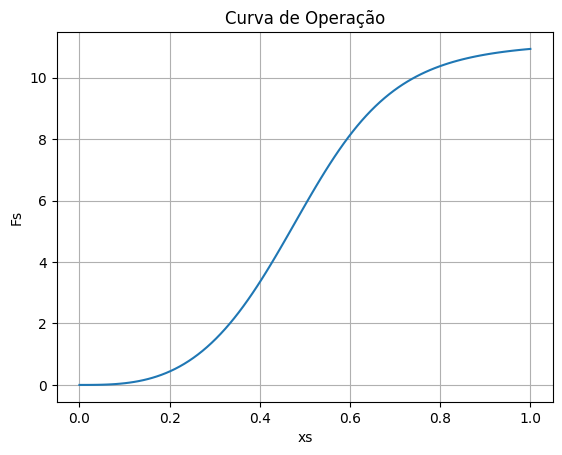

In [20]:
plt.plot(xs,ss(xs))
plt.ylabel('Fs')
plt.xlabel('xs')
plt.title('Curva de Operação')
plt.grid()

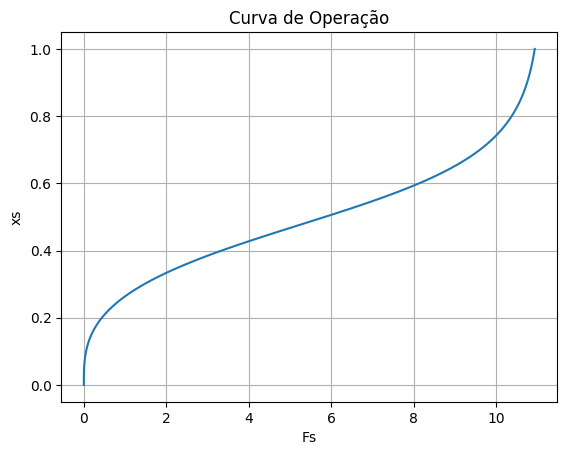

In [21]:
plt.plot(ss(xs),xs)
plt.ylabel('xs')
plt.xlabel('Fs')
plt.title('Curva de Operação')
plt.grid()

In [22]:
Fs = np.linspace(0,11)

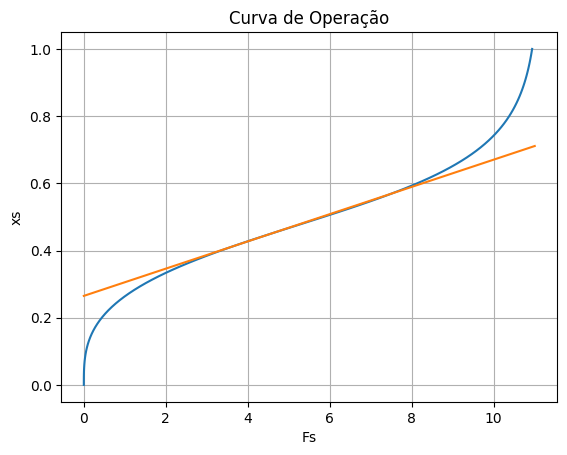

In [23]:
plt.plot(ss(xs),xs)
plt.plot(Fs, 0.04055*Fs+0.265)
plt.ylabel('xs')
plt.xlabel('Fs')
plt.title('Curva de Operação')
plt.grid()

### Passo 3: Controle SISO da Malha Rápida ($T_t$) - [Ref. Prof 1.1.2]
* **Objetivo:** Projetar um controlador PID para a temperatura do tanque ($T_t$), onde o atraso de transporte é desprezível.
* **Foco:** Rapidez de resposta e estabilidade.
* *Nota: Por restrições físicas de causalidade, a variável controlada escrava foi definida como a temperatura do tanque ($T_t$) em substituição ao distúrbio externo ($T_f$).*
- Execução de **Testes de Degrau** para levantar a curva de reação do processo.
- Obtenção dos parâmetros **FOPTD** (First-Order Plus Dead Time):
  - Ganho do Processo ($K_p$)
  - Constante de Tempo ($\tau$)
  - Tempo Morto ($\theta$)

In [ ]:
def Simulacao_MA_Temperatura(SYS, Y0, UT, dt): 
    tempoFinal = UT[-1,0] 
    TT = np.arange(start = 0, stop = tempoFinal+dt, step = dt, dtype='float') 
    nt = np.size(TT)
    ny = 4
    id_plot = [0,1,2,-1] # Boiler, Nível, Tanque, Ponta Tubulação
    
    YY = np.ones((nt,ny))@np.diag(Y0[id_plot])
    SP = np.ones((nt,ny))@np.diag(Y0[id_plot])
    
    nu = np.size(UT,1)
    UU = np.zeros((nt,nu-1)) 

    # --- Parâmetros dos Controladores (Copiados do Prof. Trierweiler) ---
    Kp      = np.array([ 1, 0.3, 0.6, 0.5])
    Ti      = np.array([ 1, 0.8, 0.8, 0.5])
    Td      = np.array([ 1, 0.0, 0.0, 0.0])
    b       = np.array([ 1, 1.0, 1.0, 1.0])
    c       = np.array([ 0,   0,  0,    0])
    UU_bias = np.array([ 0, 0.25,0.25,0.50])
    UU_min  = np.array([ 0, 0.01,0.01,0.01])
    UU_max  = np.array([ 1, 0.99,0.99,0.99])
    D_int   = np.array([ 0, 0, 0, 0])  
    I_int   = Kp * Y0[id_plot] * (1-b)
    N_filtro = 10
    
    ii = 0
    for k in np.arange(nt-1):
        if TT[k] >= UT[ii+1,0]:
            ii += 1

        UU[k,:] = UT[ii,1:nu] 
        
        # 1. Malha do Boiler (MANTIDA FECHADA - OnOff)
        SP[k,0] = UU[k,0]
        UU[k,0] = OnOff(UU[k-1,0], YY[k,0], SP[k,0]-1, SP[k,0]+1)
        
        # 2. Malha de Nível 'h' (MANTIDA FECHADA - PID)
        # Este controlador ajustará xf (válvula fria) para o tanque não secar
        jj = 1
        SP[k,jj] = UU[k,jj]
        uu = PID(SP[:,jj], YY[:,jj], k, I_int[jj], D_int[jj], dt, Kp[jj], Ti[jj], Td[jj], b[jj], c[jj],
                 N_filtro, U_bias=UU_bias[jj], Umin=UU_min[jj], Umax=UU_max[jj])
        UU[k,jj]  = uu[0] 
        I_int[jj] = uu[1]
        D_int[jj] = uu[2]
        
        # 3. MALHA DE TEMPERATURA (ABERTA PARA O DEGRAU)
        # Desligamos o PID de temperatura e controlamos a Válvula Quente (xq) manualmente
        t_degrau = 30.0 # Damos 30 min para o nível se estabilizar perfeitamente
        if TT[k] >= t_degrau:
            UU[k,2] = 0.35  # Degrau: Válvula quente abre para 35%
        else:
            UU[k,2] = 0.25  # Valor Nominal: 25%
            
        # Motor de Integração Original do Professor
        sol = solve_ivp(SYS, [TT[k],TT[k+1]], Y0, args=tuple(UU[k]), atol=1e-8, rtol=1e-8) 
        
        Y0 = sol.y[:,-1]
        YY[k+1,:] = sol.y[id_plot,-1]
                
    UU[k+1,:] = UU[k,:]  
    SP[k+1,:] = SP[k,:]
    
    # --- Plotagem Focada ---
    Plota(TT,
      { 'Tt (Tanque)':YY[:,2], 'T1 (Tubulação)': YY[:,3]},
      {'xq (Degrau Aplicado)':UU[:,2], 'xf (Ação do PID de Nível)':UU[:,1]},
      tit = "Curva de Reação FOPTD (Nível Controlado)", xlabel = 'Tempo (min)')
        
    return (TT,YY,UU)

# --- CONFIGURAÇÃO E EXECUÇÃO ---
Ta = 28 # temperatura ambiente
# Matriz UT estendida para 200 minutos para observarmos a estabilização completa
UT_degrau = np.array([
    # Time, SPTq, SPh, SP_T1,  xs,  Tf,  Td, Tinf, Fd, Sr
    [  0  ,   45,  90,    32, 0.8,  Ta,  Ta,   Ta,  0, 0],
    [ 200 ,   45,  90,    32, 0.8,  Ta,  Ta,   Ta,  0, 0]
])

# Rodando com dt = 0.5 (mesmo do original)
TT_ma, YY_ma, UU_ma = Simulacao_MA_Temperatura(ModelagemSistema, np.array([45,90]+50*[Ta]), UT_degrau, 0.05)


In [33]:
def Extrai_Parametros_FOPTD(TT, YY, UU, t_degrau, idx_y, idx_u):
    # 1. Âncora de Regime Permanente
    # Correção: Desigualdade estrita (<) para capturar o passo ANTERIOR ao degrau
    idx_degrau = np.where(TT < t_degrau)[0][-1]
    
    y_inicial = YY[idx_degrau, idx_y]
    u_inicial = UU[idx_degrau, idx_u]
    
    # Média no final da simulação
    mask_final = TT > (TT[-1] - 10)
    y_final = np.mean(YY[mask_final, idx_y])
    u_final = np.mean(UU[mask_final, idx_u])
    
    delta_y = y_final - y_inicial
    delta_u = u_final - u_inicial
    
    # 2. Ganho do Processo (Kp)
    # Com a desigualdade estrita, delta_u agora será exatamente 0.10
    Kp = delta_y / delta_u
    
    # Função interna para interpolação
    def encontra_tempo_exato(y_alvo):
        idx = np.where((TT > t_degrau) & (YY[:, idx_y] >= y_alvo))[0][0]
        
        t1, t2 = TT[idx-1], TT[idx]
        y1, y2 = YY[idx-1, idx_y], YY[idx, idx_y]
        
        if y2 == y1:
            return t2
            
        t_exato = t1 + (y_alvo - y1) * (t2 - t1) / (y2 - y1)
        return t_exato

    # 3. Tempo Morto (Teta)
    y_start = y_inicial + 0.02 * delta_y
    t_start = encontra_tempo_exato(y_start)
    Teta = t_start - t_degrau
    
    # 4. Constante de Tempo (Tau)
    y_63 = y_inicial + 0.632 * delta_y
    t_63 = encontra_tempo_exato(y_63)
    
    Tau = t_63 - t_start
    
    return Kp, Teta, Tau, y_inicial, y_final

# --- EXECUÇÃO E IMPRESSÃO ---

t_do_degrau = 30.0

# idx_y = 3 ('T1', final da tubulação) | idx_u = 2 ('xq', válvula quente)
Kp_T1, Teta_T1, Tau_T1, y0_T1, yf_T1 = Extrai_Parametros_FOPTD(TT_ma, YY_ma, UU_ma, t_do_degrau, idx_y=3, idx_u=2)

print("="*40)
print(" PARÂMETROS IDENTIFICADOS: MALHA T1 (TUBULAÇÃO)")
print("="*40)
print(f"Temperatura Inicial: {y0_T1:.4f} °C")
print(f"Temperatura Final:   {yf_T1:.4f} °C")
print("-" * 40)
print(f"Ganho (Kp):          {Kp_T1:.4f} °C/%")
print(f"Tempo Morto (θ):     {Teta_T1:.4f} min")
print(f"Constante Tempo (τ): {Tau_T1:.4f} min")
print("="*40)

 PARÂMETROS IDENTIFICADOS: MALHA T1 (TUBULAÇÃO)
Temperatura Inicial: 31.9297 °C
Temperatura Final:   34.1281 °C
----------------------------------------
Ganho (Kp):          21.9841 °C/%
Tempo Morto (θ):     0.5721 min
Constante Tempo (τ): 4.2075 min


In [34]:
def Simulacao_MF_SISO_Tanque(SYS, Y0, UT, dt): 
    tempoFinal = UT[-1,0] 
    TT = np.arange(start = 0, stop = tempoFinal+dt, step = dt, dtype='float') 
    nt = np.size(TT)
    ny = 4
    id_plot = [0,1,2,-1] # Boiler, Nível, Tanque, Tubulação
    
    YY = np.ones((nt,ny))@np.diag(Y0[id_plot])
    SP = np.ones((nt,ny))@np.diag(Y0[id_plot])
    
    nu = np.size(UT,1)
    UU = np.zeros((nt,nu-1)) 

    # ---------------------------------------------------------
    # PARÂMETROS SKOGESTAD (Apenas Tt -> xq)
    # Sintonia agressiva pois o tempo morto do tanque é quase nulo (\theta = 0.14)
    # ---------------------------------------------------------
    Kc_Nivel, Ti_Nivel = 0.3, 0.8
    Kc_Tanque, Ti_Tanque = 0.6366, 1.1560 
    
    I_int_Nivel  = Kc_Nivel * Y0[id_plot[1]] * (1 - 1.0)
    I_int_Tanque = Kc_Tanque * Y0[id_plot[2]] * (1 - 1.0)
    
    ii = 0
    for k in np.arange(nt-1):
        if TT[k] >= UT[ii+1,0]:
            ii += 1

        UU[k,:] = UT[ii,1:nu] 
        
        # 1. Malha do Boiler (OnOff)
        SP[k,0] = UU[k,0]
        UU[k,0] = OnOff(UU[k-1,0], YY[k,0], SP[k,0]-1, SP[k,0]+1)
        
        # 2. Malha de Nível
        SP[k,1] = UU[k,1]
        uu_n = PID(SP[:,1], YY[:,1], k, I_int_Nivel, 0, dt, Kc_Nivel, Ti_Nivel, 0, 1, 0, 10, U_bias=0.25, Umin=0.01, Umax=0.99)
        UU[k,1]  = uu_n[0] 
        I_int_Nivel = uu_n[1]
        
        # 3. MALHA SISO TANQUE (Lê Tt, Atua em xq)
        # Atenção: SP[:,2] agora é exigido para o Tanque, não para a tubulação
        SP[k,2] = UU[k,2]
        uu_t = PID(SP[:,2], YY[:,2], k, I_int_Tanque, 0, dt, Kc_Tanque, Ti_Tanque, 0, 1, 0, 10, U_bias=0.25, Umin=0.01, Umax=0.99)
        UU[k,2]  = uu_t[0] 
        I_int_Tanque = uu_t[1]
        
        # Integração da Planta
        sol = solve_ivp(SYS, [TT[k],TT[k+1]], Y0, args=tuple(UU[k]), atol=1e-8, rtol=1e-8) 
        
        Y0 = sol.y[:,-1]
        YY[k+1,:] = sol.y[id_plot,-1]
                
    UU[k+1,:] = UU[k,:]  
    SP[k+1,:] = SP[k,:]
    
    # Plotagem
    Plota(TT,
      { 'Tt (Tanque)':YY[:,2], 'Setpoint Tt':SP[:,2], 'Tf (Água Fria)': UU[:,4]},
      {'xq (Ação do PID)':UU[:,2]},
      tit = "SISO Tanque (Sem Tubulação): Resposta Rápida", xlabel = 'Tempo (min)')
        
    return TT, YY, UU, SP 

# --- CRONOGRAMA DE EVENTOS ---
Ta = 28 
Y0_Tanque = np.array([45, 90] + 50*[Ta])

# Testamos um degrau direto no tanque (32 -> 35) e o mesmo choque térmico em t=150
UT_SISO_Tanque = np.array([
    # Time, SPTq, SPh, SP_Tt,  xs,  Tf,  Td, Tinf, Fd, Sr
    [  0  ,   45,  90,    32, 0.8,  Ta,  Ta,   Ta,  0, 0],
    [ 50  ,   45,  90,    35, 0.8,  Ta,  Ta,   Ta,  0, 0],
    [ 150 ,   45,  90,    35, 0.8,  20,  Ta,   Ta,  0, 0],
    [ 300 ,   45,  90,    35, 0.8,  20,  Ta,   Ta,  0, 0]
])

print("Executando simulação SISO do Tanque...")
TT_tq, YY_tq, UU_tq, SP_tq = Simulacao_MF_SISO_Tanque(ModelagemSistema, Y0_Tanque, UT_SISO_Tanque, dt=0.05)

Executando simulação SISO do Tanque...


### Passo 4: Controle SISO da Malha com Atraso ($T_1$) - [Ref. Prof 1.1.1]
* **Objetivo:** Projetar um controlador PID para a temperatura de consumo final ($T_1$).
* **Desafio:** Mitigar a degradação de performance causada pelos 50 metros de tubulação ($	heta$).
* **Método:** Aplicação da sintonia de **Skogestad (SIMC)** para garantir robustez.

In [ ]:
def Simulacao_MF_SISO_Tubulacao_Completa(SYS, Y0, UT, dt): 
    tempoFinal = UT[-1,0] 
    TT = np.arange(start = 0, stop = tempoFinal+dt, step = dt, dtype='float') 
    nt = np.size(TT)
    ny = 4
    id_plot = [0,1,2,-1] # Boiler, Nível, Tanque, Tubulação
    
    YY = np.ones((nt,ny))@np.diag(Y0[id_plot])
    SP = np.ones((nt,ny))@np.diag(Y0[id_plot])
    
    nu = np.size(UT,1)
    UU = np.zeros((nt,nu-1)) 

    # ---------------------------------------------------------
    # PARÂMETROS SKOGESTAD (T1 -> xq)
    # ---------------------------------------------------------
    Kp      = np.array([ 1.0,  0.3,  0.1673 ]) 
    Ti      = np.array([ 1.0,  0.8,  4.2075 ]) 
    Td      = np.array([ 1.0,  0.0,  0.0    ])
    b       = np.array([ 1.0,  1.0,  1.0    ])
    c       = np.array([ 0.0,  0.0,  0.0    ])
    UU_bias = np.array([ 0.0,  0.25, 0.25   ])
    UU_min  = np.array([ 0.0,  0.01, 0.01   ])
    UU_max  = np.array([ 1.0,  0.99, 0.99   ])
    D_int   = np.array([ 0.0,  0.0,  0.0    ])  
    
    I_int   = np.array([ 0.0, Kp[1]*Y0[id_plot[1]]*(1-b[1]), Kp[2]*Y0[id_plot[3]]*(1-b[2]) ])
    N_filtro = 10
    
    ii = 0
    for k in np.arange(nt-1):
        if TT[k] >= UT[ii+1,0]:
            ii += 1

        UU[k,:] = UT[ii,1:nu] 
        
        # 1. Malha do Boiler (OnOff)
        SP[k,0] = UU[k,0]
        UU[k,0] = OnOff(UU[k-1,0], YY[k,0], SP[k,0]-1, SP[k,0]+1)
        
        # 2. Malha de Nível (Mantém h = 90)
        jj = 1
        SP[k,jj] = UU[k,jj]
        uu = PID(SP[:,jj], YY[:,jj], k, I_int[jj], D_int[jj], dt, Kp[jj], Ti[jj], Td[jj], b[jj], c[jj],
                 N_filtro, U_bias=UU_bias[jj], Umin=UU_min[jj], Umax=UU_max[jj])
        UU[k,jj]  = uu[0] 
        I_int[jj] = uu[1]
        
        # 3. MALHA SISO (T1 -> xq)
        jj = 2
        SP[k,jj] = UU[k,jj]
        uu_t1 = PID(SP[:,jj], YY[:,3], k, I_int[jj], D_int[jj], dt, Kp[jj], Ti[jj], Td[jj], b[jj], c[jj],
                 N_filtro, U_bias=UU_bias[jj], Umin=UU_min[jj], Umax=UU_max[jj])
        UU[k,jj]  = uu_t1[0] 
        I_int[jj] = uu_t1[1]
        
        # Integração da Planta
        sol = solve_ivp(SYS, [TT[k],TT[k+1]], Y0, args=tuple(UU[k]), atol=1e-8, rtol=1e-8) 
        
        Y0 = sol.y[:,-1]
        YY[k+1,:] = sol.y[id_plot,-1]
                
    UU[k+1,:] = UU[k,:]  
    SP[k+1,:] = SP[k,:]
    
    # Plotagem atualizada para mostrar a variável de distúrbio (UU[:,4] = Tf)
    Plota(TT,
      { 'T1 (Consumo)':YY[:,3], 'Setpoint T1':SP[:,2], 'Tf (Água Fria)': UU[:,4]},
      {'xq (Ação do PID)':UU[:,2]},
      tit = "SISO Oficial: Servo-Controle e Rejeição a Distúrbio", xlabel = 'Tempo (min)')
        
    return TT, YY, UU, SP 

# --- CRONOGRAMA DE EVENTOS DO TESTE ---
Ta = 28 
Y0_MF = np.array([45, 90] + 50*[Ta])

# Eventos:
# t=0   : Inicialização (SP=32, Tf=28)
# t=50  : Degrau de Setpoint (SP=35, Tf=28) -> Evita saturação da válvula
# t=150 : Choque Térmico (SP=35, Tf=15)
UT_SISO_Combinado = np.array([
    # Time, SPTq, SPh, SP_T1,  xs,  Tf,  Td, Tinf, Fd, Sr
    [  0  ,   45,  90,    32, 0.8,  Ta,  Ta,   Ta,  0, 0],
    [ 50  ,   45,  90,    35, 0.8,  Ta,  Ta,   Ta,  0, 0],
    [ 150 ,   45,  90,    35, 0.8,  20,  Ta,   Ta,  0, 0],
    [ 300 ,   45,  90,    35, 0.8,  20,  Ta,   Ta,  0, 0]
])

print("Executando simulação final SISO...")
TT_mf, YY_mf, UU_mf, SP_mf_SISO = Simulacao_MF_SISO_Tubulacao_Completa(ModelagemSistema, Y0_MF, UT_SISO_Combinado, dt=0.05)

Executando simulação final SISO...


In [ ]:
def Extrai_Parametros_FOPTD_Escravo(TT, YY, UU, t_degrau, idx_y, idx_u):
    """
    Algoritmo de extração matemática com interpolação linear e filtro
    de ruído numérico. Ancorado no passo imediatamente anterior ao degrau.
    """
    # 1. Âncora de Regime Permanente (Desigualdade estrita)
    idx_degrau = np.where(TT < t_degrau)[0][-1]
    
    y_inicial = YY[idx_degrau, idx_y]
    u_inicial = UU[idx_degrau, idx_u]
    
    # Média no final da simulação (Regime Permanente pós-degrau)
    mask_final = TT > (TT[-1] - 10)
    y_final = np.mean(YY[mask_final, idx_y])
    u_final = np.mean(UU[mask_final, idx_u])
    
    delta_y = y_final - y_inicial
    delta_u = u_final - u_inicial
    
    # 2. Ganho do Processo (Kp)
    Kp = delta_y / delta_u
    
    # Motor de Interpolação Linear
    def encontra_tempo_exato(y_alvo):
        idx = np.where((TT > t_degrau) & (YY[:, idx_y] >= y_alvo))[0][0]
        t1, t2 = TT[idx-1], TT[idx]
        y1, y2 = YY[idx-1, idx_y], YY[idx, idx_y]
        
        if y2 == y1:
            return t2
        return t1 + (y_alvo - y1) * (t2 - t1) / (y2 - y1)

    # 3. Tempo Morto (Teta)
    # Filtro de 2% para ignorar o chattering da válvula de nível
    y_start = y_inicial + 0.02 * delta_y
    t_start = encontra_tempo_exato(y_start)
    
    # Trava matemática: Se a resposta for instantânea, assumimos um tempo morto 
    # numérico mínimo para evitar divisão por zero nas fórmulas de Skogestad.
    Teta = max(0.0001, t_start - t_degrau)
    
    # 4. Constante de Tempo (Tau)
    y_63 = y_inicial + 0.632 * delta_y
    t_63 = encontra_tempo_exato(y_63)
    Tau = t_63 - t_start
    
    return Kp, Teta, Tau, y_inicial, y_final

# --- EXECUÇÃO E IMPRESSÃO (MALHA DO TANQUE) ---
# t_do_degrau = 30.0 (O momento em que abrimos a válvula xq na simulação MA)
# idx_y = 2 corresponde a 'Tt' (Temperatura dentro do Tanque de Mistura)
# idx_u = 2 corresponde a 'xq' (Válvula de Água Quente)

Kp_Tt, Teta_Tt, Tau_Tt, y0_Tt, yf_Tt = Extrai_Parametros_FOPTD_Escravo(TT_ma, YY_ma, UU_ma, 30.0, idx_y=2, idx_u=2)

print("="*45)
print(" PARÂMETROS IDENTIFICADOS: MALHA Tt (TANQUE)")
print("="*45)
print(f"Temperatura Inicial: {y0_Tt:.4f} °C")
print(f"Temperatura Final:   {yf_Tt:.4f} °C")
print("-" * 45)
print(f"Ganho (Kp):          {Kp_Tt:.4f} °C/%")
print(f"Tempo Morto (θ):     {Teta_Tt:.4f} min")
print(f"Constante Tempo (τ): {Tau_Tt:.4f} min")
print("="*45)

 PARÂMETROS IDENTIFICADOS: MALHA Tt (TANQUE)
Temperatura Inicial: 32.1341 °C
Temperatura Final:   34.4242 °C
---------------------------------------------
Ganho (Kp):          22.9005 °C/%
Tempo Morto (θ):     0.1445 min
Constante Tempo (τ): 4.2132 min


### Passo 5: Arquitetura de Controle em Cascata - [Ref. Prof 1.1.3]
* **Estrutura:** Implementação de uma malha mestre (externa) e uma malha escrava (interna).
    * **Mestre:** Supervisiona $T_1$ e dita o setpoint térmico.
    * **Escravo:** Atua diretamente na válvula quente para corrigir distúrbios antes que percorram a tubulação.
* **Ajuste Fino:** Implementação de *Detuning* no mestre para evitar ressonância com o ruído do boiler.



### Explicação Estrutural: Simulação de Controle em Cascata

Este bloco de código substitui a arquitetura SISO unidimensional por uma topologia de controle avançado. O objetivo central é eliminar a vulnerabilidade do sistema ao atraso de transporte ($\theta$) da tubulação frente a distúrbios de carga (água fria).

Abaixo está a desconstrução técnica do que o código executa, dividida pelos componentes críticos do algoritmo:

#### 1. Gerenciamento de Memória Dinâmica
Diferente do SISO, onde o *setpoint* da válvula é direto, a Cascata exige comunicação entre dois controladores.
* **A variável `SP_Tanque_Cascata`:** O código aloca um vetor dedicado para gravar o sinal de saída do Controlador Mestre a cada instante de tempo `dt`. Este vetor serve como a ponte de dados que alimenta a entrada (o *setpoint*) do Controlador Escravo.

#### 2. Separação de Frequências (A Sintonia)
O código define duas dinâmicas de controle rigorosamente separadas para garantir a estabilidade (evitar ressonância acoplada):
* **Malha Escrava ($K_c = 0.6366, T_i = 1.1560$):** Sintonizada matematicamente pelo método SIMC para ser **rápida e agressiva**. Seu trabalho é aniquilar distúrbios na temperatura do tanque ($T_t$) antes que eles entrem na tubulação.
* **Malha Mestra ($K_c = 0.8, T_i = 1.5$):** Propositalmente **desafinada (Detuning)** em relação ao cálculo FOPTD original. Atua como um supervisor lento e um filtro passa-baixa. Se mantivéssemos o ganho original ($\approx 4.9$), o Mestre amplificaria o ruído do controle On-Off do boiler, gerando um Ciclo Limite (saturação oscilatória da válvula).

#### 3. O Motor da Cascata (O Loop de Integração)
Dentro do loop `for k in np.arange(nt-1):`, a hierarquia de execução obedece à causalidade do fluxo de informações:
* **Passo A (Mestre):** A função `PID` lê a temperatura real do chuveiro ($T_1$) e calcula qual deve ser a temperatura ideal da água dentro do tanque ($SP_{Tt}$).
    * *Trava Operacional:* O Mestre possui restrições térmicas físicas (`Umin=20.0`, `Umax=50.0`). Ele é impedido por código de exigir que a água do tanque congele ou ultrapasse a capacidade de aquecimento.
* **Passo B (Escravo):** A segunda função `PID` lê a temperatura real do tanque ($T_t$), compara com o valor ditado pelo Mestre no Passo A, e calcula a porcentagem de abertura mecânica da válvula de água quente ($x_q$).
    * *Trava Operacional:* O Escravo possui restrições físicas do atuador (`Umin=0.01`, `Umax=0.99`), impedindo travamentos matemáticos (Windup) quando a válvula atinge o fim de curso.

#### 4. Integração da Planta
Após as decisões dos PIDs, a função `solve_ivp` resolve o sistema de Equações Diferenciais Ordinárias (EDOs) não-lineares da planta (`ModelagemSistema`) para o pequeno passo de tempo `dt`, atualizando os vetores de estado de nível e temperatura para a próxima iteração.

#### 5. Cronograma de Testes (A Matriz `UT_Casc`)
O código consolida a prova de desempenho em uma única linha do tempo:
1.  **$t=0$ a $50$:** Acomodação inicial em **32°C**.
2.  **$t=50$:** **Teste de Servo-Controle.** Degrau de *setpoint* para **35°C**. O Mestre calcula uma rampa térmica para o tanque, e o Escravo executa a abertura da válvula suavemente.
3.  **$t=150$:** **Teste de Controle Regulatório.** A temperatura da água externa ($T_f$) sofre um choque de **28°C** para **20°C**. O Escravo, tendo o sensor imerso no tanque, acusa a queda instantaneamente e reage na válvula antes que o Mestre (na ponta da tubulação) perceba a variação, blindando o consumidor final contra o distúrbio.

In [ ]:
def Simulacao_MF_Cascata(SYS, Y0, UT, dt): 
    """
    Simulação em Malha Fechada com arquitetura em Cascata.
    Mestre: Controla a temperatura no consumo (T1) ditando o SP do tanque.
    Escravo: Controla a temperatura no tanque (Tt) manipulando a válvula quente (xq).
    """
    tempoFinal = UT[-1,0] 
    TT = np.arange(start = 0, stop = tempoFinal+dt, step = dt, dtype='float') 
    nt = np.size(TT)
    ny = 4
    id_plot = [0,1,2,-1] # Boiler, Nível, Tanque, Tubulação
    
    YY = np.ones((nt,ny))@np.diag(Y0[id_plot])
    SP = np.ones((nt,ny))@np.diag(Y0[id_plot])
    
    nu = np.size(UT,1)
    UU = np.zeros((nt,nu-1)) 
    
    # Vetor para armazenar a decisão do Mestre (Setpoint para o Escravo)
    SP_Tanque_Cascata = np.ones(nt) * Y0[id_plot[2]]

    # ---------------------------------------------------------
    # SINTONIA SKOGESTAD (SIMC) - PARÂMETROS CALCULADOS
    # ---------------------------------------------------------
    # Malha de Nível (Original)
    Kc_Nivel, Ti_Nivel = 0.3, 0.8
    
    # Malha Escrava (Tt -> xq) - Foco em rapidez para rejeitar Tf
    Kc_Escravo, Ti_Escravo = 0.6366, 1.1560
    
    # Malha Mestra (T1 -> SP_Tt) - Foco em precisão no consumo
    #Kc_Mestre, Ti_Mestre   = 4.9260, 3.4208

    # Malha Mestra (T1 -> SP_Tt) - Desafinada para estabilidade (K_c < 1.0)
    Kc_Mestre, Ti_Mestre   = 0.8, 1.5
    
    # Estados iniciais dos integradores
    I_int_Nivel   = Kc_Nivel * Y0[id_plot[1]] * (1 - 1.0)
    I_int_Escravo = Kc_Escravo * Y0[id_plot[2]] * (1 - 1.0)
    I_int_Mestre  = Kc_Mestre * Y0[id_plot[3]] * (1 - 1.0)
    
    ii = 0
    for k in np.arange(nt-1):
        if TT[k] >= UT[ii+1,0]:
            ii += 1

        UU[k,:] = UT[ii,1:nu] 
        
        # 1. Malha do Boiler (MANTIDA ON-OFF)
        SP[k,0] = UU[k,0]
        UU[k,0] = OnOff(UU[k-1,0], YY[k,0], SP[k,0]-1, SP[k,0]+1)
        
        # 2. Malha de Nível (Mantém h constante mexendo em xf)
        SP[k,1] = UU[k,1]
        uu_n = PID(SP[:,1], YY[:,1], k, I_int_Nivel, 0, dt, Kc_Nivel, Ti_Nivel, 0, 1, 0, 10, U_bias=0.25, Umin=0.01, Umax=0.99)
        UU[k,1] = uu_n[0] 
        I_int_Nivel = uu_n[1]
        
        # 3. ARQUITETURA EM CASCATA
        # ---------------------------------------------------------
        # PASSO A: CONTROLADOR MESTRE (Lê T1 da ponta, calcula SP para o tanque)
        # SP[:,2] é o valor desejado no chuveiro (ex: 35°C)
        SP[k,2] = UU[k,2] 
        uu_m = PID(SP[:,2], YY[:,3], k, I_int_Mestre, 0, dt, Kc_Mestre, Ti_Mestre, 0, 1, 0, 10, 
                   U_bias=35.0, Umin=20.0, Umax=50.0) # Bias térmico do tanque
        SP_Tanque_Cascata[k] = uu_m[0]
        I_int_Mestre = uu_m[1]
        
        # PASSO B: CONTROLADOR ESCRAVO (Lê Tt do tanque, segue o Mestre, atua em xq)
        uu_e = PID(SP_Tanque_Cascata, YY[:,2], k, I_int_Escravo, 0, dt, Kc_Escravo, Ti_Escravo, 0, 1, 0, 10, 
                   U_bias=0.25, Umin=0.01, Umax=0.99) # Bias mecânico da válvula
        UU[k,2] = uu_e[0] 
        I_int_Escravo = uu_e[1]
        # ---------------------------------------------------------
        
        # Integração Numérica
        sol = solve_ivp(SYS, [TT[k],TT[k+1]], Y0, args=tuple(UU[k]), atol=1e-8, rtol=1e-8) 
        Y0 = sol.y[:,-1]
        YY[k+1,:] = sol.y[id_plot,-1]
                
    UU[k+1,:] = UU[k,:]  
    SP[k+1,:] = SP[k,:]
    SP_Tanque_Cascata[-1] = SP_Tanque_Cascata[-2]
    
    # Plotagem demonstrando a hierarquia de controle
    Plota(TT,
      { 'T1 (Consumo)':YY[:,3], 'SP Mestre (T1)':SP[:,2], 'Tt (Tanque)':YY[:,2], 'Tf (Água Fria)': UU[:,4] },
      {'xq (Válvula)':UU[:,2]},
      tit = "Controle em Cascata: Resposta Estabilizada", xlabel = 'Tempo (min)')
        
    return TT, YY, UU, SP

# --- EXECUÇÃO DO TESTE ---
Ta = 28 
Y0_Casc = np.array([45, 90] + 50*[Ta])

# Teste: Servo-controle (32->35) e Choque Térmico (28->20) em t=150
UT_Casc = np.array([
    [  0  ,   45,  90,    32, 0.8,  Ta,  Ta,   Ta,  0, 0],
    [ 50  ,   45,  90,    35, 0.8,  Ta,  Ta,   Ta,  0, 0],
    [ 150 ,   45,  90,    35, 0.8,  20,  Ta,   Ta,  0, 0],
    [ 300 ,   45,  90,    35, 0.8,  20,  Ta,   Ta,  0, 0]
])

print("Iniciando Simulação em Cascata...")
TT_c, YY_c, UU_c, SP_mf_Cascata = Simulacao_MF_Cascata(ModelagemSistema, Y0_Casc, UT_Casc, dt=0.05)

Iniciando Simulação em Cascata...


### Passo 6: Análise Quantitativa de Desempenho (IAE)
* Cálculo da **Integral do Erro Absoluto (IAE)** para comparar matematicamente as estratégias.
* Validação da redução do desconforto térmico ao usuário sob condições de choque térmico na rede de água fria.

In [ ]:

def Calcula_IAE_Puro(TT, PV_vector, SP_vector, t_inicio, dt):
    # Filtra apenas o tempo após o distúrbio
    mask = TT >= t_inicio
    
    # Sincroniza tamanhos (evita erro de simulações incompletas)
    size = min(len(mask), len(PV_vector), len(SP_vector))
    m = mask[:size]
    
    # Cálculo: Erro = Abs(Setpoint - Process Variable)
    erro = np.abs(SP_vector[:size][m] - PV_vector[:size][m])
    return np.sum(erro) * dt

# --- Extração dos Dados ---
# SISO: O Setpoint de T1 está na coluna 2 de SP_mf_SISO. T1 medida está na coluna 3 de YY_mf.
iae_siso = Calcula_IAE_Puro(TT_mf, YY_mf[:, 3], SP_mf_SISO[:, 2], 150.0, 0.05)

# CASCATA: O Setpoint de T1 está na coluna 2 de SP_mf_Cascata. T1 medida está na coluna 3 de YY_c.
iae_casc = Calcula_IAE_Puro(TT_c, YY_c[:, 3], SP_mf_Cascata[:, 2], 150.0, 0.05)

# --- Verificação de Sanidade ---
if iae_casc == 0:
    print("AVISO: IAE Cascata deu ZERO. Verifique se você re-executou a célula da simulação!")
else:
    melhoria = ((iae_siso - iae_casc) / iae_siso) * 100
    print("="*55)
    print(" COMPARATIVO FINAL DE PERFORMANCE (VALIDADO)")
    print("="*55)
    print(f"IAE Malha SISO:    {iae_siso:.4f} °C.min")
    print(f"IAE Malha Cascata: {iae_casc:.4f} °C.min")
    print("-" * 55)
    print(f"REDUÇÃO DO ERRO:   {melhoria:.2f}%")
    print("="*55)

 COMPARATIVO FINAL DE PERFORMANCE (VALIDADO)
IAE Malha SISO:    12.9089 °C.min
IAE Malha Cascata: 5.4513 °C.min
-------------------------------------------------------
REDUÇÃO DO ERRO:   57.77%
